# 🛍️ Sephora — Segmentation Client
## Notebook 02 — Clustering Pipeline

Ce notebook implémente le pipeline complet de segmentation client :
1. Audit des features → 2. Sélection → 3. Preprocessing → 4. Cercle des corrélations →
5. K-Scan → 6. Modèle final → 7. Profiling des segments → 8. Export

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

from src.config import (
    DATA_PROCESSED_PATH, RANDOM_STATE, K_RANGE,
    FEATURES_DROP, FEATURES_CONTINUOUS, FEATURES_ONEHOT,
    FEATURE_CATEGORIES, CATEGORY_COLORS,
)
from src.preprocessing import preprocess_for_clustering
from src.clustering import (
    evaluate_kmeans_k_range, get_top_k_candidates,
    run_kmeans_final, run_hierarchical, log_clustering_run,
)
from src.visualization import plot_correlation_circle, plot_elbow_curves

os.makedirs("figures", exist_ok=True)

# --- MLflow experiment setup (R1.5) ---
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("sephora-customer-segmentation")
print("MLflow URI:", mlflow.get_tracking_uri())

MLflow URI: sqlite:///mlflow.db


In [2]:
df_customers = pd.read_csv(DATA_PROCESSED_PATH + "customers_features.csv")
print(f"Loaded customers_features.csv — {df_customers.shape[0]:,} clients × {df_customers.shape[1]} colonnes")

Loaded customers_features.csv — 64,469 clients × 54 colonnes


---
# Section 2 — Audit des features

Chaque feature conservée est classée dans l'une des 6 catégories marketing définies dans `src/config.py → FEATURE_CATEGORIES`.
Ce référentiel guide l'interprétation métier des clusters.

| Catégorie | Description | Exemples |
|---|---|---|
| **profil** | Qui est le client — traits socio-démographiques | `age`, `gender`, `country`, `loyalty_numeric` |
| **valeur** | Combien vaut le client — indicateurs RFM | `recency_days`, `frequency`, `monetary_total` |
| **affinite_produit** | Ce que le client achète — ratios produit/marché | `axe_skincare_ratio`, `dominant_axe` |
| **comportement** | Comment le client achète — panier, marques | `avg_units_per_basket`, `nb_unique_brands` |
| **canal** | Où le client achète — distribution omnicanale | `store_ratio`, `dominant_channel` |
| **dates** | Ancienneté fidélité | `subscription_tenure_days` |

In [3]:
from src.config import FEATURE_CATEGORIES

print("=== FEATURE_CATEGORIES ===\n")
for cat, feats in FEATURE_CATEGORIES.items():
    print(f"  {cat:20s} ({len(feats):2d} features) : {feats}")
print(f"\nTotal features référencées : {sum(len(v) for v in FEATURE_CATEGORIES.values())}")

=== FEATURE_CATEGORIES ===

  profil               ( 4 features) : ['age', 'gender', 'country', 'loyalty_numeric']
  valeur               ( 6 features) : ['recency_days', 'frequency', 'monetary_total', 'monetary_avg', 'avg_basket_size_eur', 'discount_rate']
  affinite_produit     ( 9 features) : ['axe_make_up_ratio', 'axe_skincare_ratio', 'axe_fragrance_ratio', 'axe_haircare_ratio', 'axe_others_ratio', 'market_selective_ratio', 'market_exclusive_ratio', 'market_sephora_ratio', 'axis_diversity']
  comportement         ( 2 features) : ['avg_units_per_basket', 'nb_unique_stores']
  canal                ( 3 features) : ['store_ratio', 'click_collect_ratio', 'dominant_channel']
  dates                ( 1 features) : ['subscription_tenure_days']

Total features référencées : 25


---
# Section 3 — Sélection des features

Avant le preprocessing, les features suivantes ont été retirées du pipeline car elles ne constituent
pas des leviers marketing actionnables (`src/config.py → FEATURES_DROP`).

| Variable supprimée | Catégorie | Raison |
|---|---|---|
| `is_new_customer` | Zero variance | Constant = 1 pour toutes les lignes |
| `total_sales_eur` / `total_transactions` / `avg_sales_eur` | Doublons exacts | Dupliquent `monetary_total`, `frequency`, `monetary_avg` |
| `salesVatEUR_first_purchase` / `first_purchase_channel` | Doublons exacts | Dupliquent `first_purchase_amount`, `channel_recruitment` |
| `monetary_total_capped` / `frequency_capped` | Doublons winsorisés | Doublons de `monetary_total`, `frequency` |
| `loyalty_status` | Redondant | Version string de `loyalty_numeric` |
| `Axe_Desc_first_purchase` | Brut | Version non nettoyée de `first_purchase_axe` |
| `last_purchase_date` / `first_purchase_date` / `subscription_date` | Dates brutes | `recency_days` et `subscription_tenure_days` conservés |
| `is_outlier` | Flag opérationnel | Pas une feature comportementale |
| `total_quantity` / `total_lines` | Volume pur | `avg_units_per_basket` suffit et est normalisé |
| `customer_city` | Trop granulaire | ~12K modalités, inutilisable en clustering |
| `first_purchase_amount` / `channel_recruitment` / `first_purchase_axe` | Passé lointain | Ne reflètent plus le comportement actuel |
| `age_category` / `age_generation` | Redondant | Redondants avec `age` (continu, plus riche) |
| `total_discount_eur` / `cc_transactions` | Redondant | `discount_rate` et `click_collect_ratio` existent déjà |
| `dominant_axe` | Redondant | `argmax(axe_*_ratio)` — information redondante avec les 5 ratios continus |
| `dominant_market` | Redondant | `argmax(market_*_ratio)` — information redondante avec les 4 ratios continus |

**Résultat attendu :** 25 features continues + 9 dummies One-Hot (gender, dominant_channel, country) + 2 indicateurs de manquants = **36 features**.

In [4]:
from src.config import FEATURES_DROP, FEATURES_CONTINUOUS, FEATURES_ONEHOT

print(f"FEATURES_DROP ({len(FEATURES_DROP)} features) :")
for f in FEATURES_DROP:
    print(f"  - {f}")

# Vérifier qu'aucune feature supprimée n'apparaît dans les listes actives
suppressed_in_active = [f for f in FEATURES_DROP if f in FEATURES_CONTINUOUS + FEATURES_ONEHOT]
assert len(suppressed_in_active) == 0, f"Features supprimées encore actives : {suppressed_in_active}"
print(f"\n✓ Aucune feature supprimée dans FEATURES_CONTINUOUS ({len(FEATURES_CONTINUOUS)}) + FEATURES_ONEHOT ({len(FEATURES_ONEHOT)})")

FEATURES_DROP (29 features) :
  - is_new_customer
  - total_sales_eur
  - total_transactions
  - avg_sales_eur
  - salesVatEUR_first_purchase
  - first_purchase_channel
  - monetary_total_capped
  - frequency_capped
  - loyalty_status
  - Axe_Desc_first_purchase
  - last_purchase_date
  - first_purchase_date
  - subscription_date
  - is_outlier
  - dominant_axe
  - dominant_market
  - total_quantity
  - total_lines
  - customer_city
  - first_purchase_amount
  - channel_recruitment
  - first_purchase_axe
  - age_category
  - age_generation
  - total_discount_eur
  - cc_transactions
  - estore_ratio
  - market_others_ratio
  - nb_unique_brands

✓ Aucune feature supprimée dans FEATURES_CONTINUOUS (22) + FEATURES_ONEHOT (3)


---
# Section 4 — Preprocessing

Le pipeline `preprocess_for_clustering()` enchaîne 3 étapes :

1. **Imputation** — médiane pour les numériques, `'Unknown'` pour les catégorielles, indicateurs de manquants (`has_age_info`, `has_first_purchase_info`)
2. **Encodage One-Hot** — 5 variables catégorielles → 18 dummies (`gender`, `dominant_channel`, `dominant_axe`, `dominant_market`, `country`)
3. **Scaling** — `StandardScaler` sur toutes les features (mean≈0, std≈1) pour que les distances euclidiennes soient homogènes

In [5]:
X_scaled, transformers = preprocess_for_clustering(df_customers, return_transformers=True)

=== Missing Rate per Feature ===
  age: 8617 missing (13.37%)
  age_category: 19638 missing (30.46%)
  age_generation: 20937 missing (32.48%)
  customer_city: 3371 missing (5.23%)
  subscription_date: 503 missing (0.78%)
  channel_recruitment: 40418 missing (62.69%)
  salesVatEUR_first_purchase: 40418 missing (62.69%)
  Axe_Desc_first_purchase: 40418 missing (62.69%)
  subscription_tenure_days: 503 missing (0.78%)
  first_purchase_axe: 40418 missing (62.69%)
  first_purchase_channel: 40418 missing (62.69%)
  first_purchase_amount: 40418 missing (62.69%)
Dropped 29 useless features: ['is_new_customer', 'total_sales_eur', 'total_transactions', 'avg_sales_eur', 'salesVatEUR_first_purchase', 'first_purchase_channel', 'monetary_total_capped', 'frequency_capped', 'loyalty_status', 'Axe_Desc_first_purchase', 'last_purchase_date', 'first_purchase_date', 'subscription_date', 'is_outlier', 'dominant_axe', 'dominant_market', 'total_quantity', 'total_lines', 'customer_city', 'first_purchase_amount

  Imputed age: 8617 NaN → median (38.00)
  Imputed subscription_tenure_days: 503 NaN → median (2200.00)


  One-hot encoded 3 features → 9 dummy columns



=== Preprocessing Complete ===
  Final shape: (64469, 33)
  Continuous features: 22
  One-hot encoded: 3 → 9 dummies
  Frequency encoded: 0
  Missing indicators: 2 (has_age_info, has_first_purchase_info)
  Mean range: [-0.000000, 0.000000] ≈ 0 ✓
  Std range:  [1.000000, 1.000000] ≈ 1 ✓


In [6]:
assert X_scaled.shape[1] == 33, f"Expected 33 features, got {X_scaled.shape[1]}"
assert X_scaled.isnull().sum().sum() == 0, "NaN values found"
assert not np.isinf(X_scaled.values).any(), "Inf values found"
print(f"X_scaled shape : {X_scaled.shape}")
print(f"Mean range     : [{X_scaled.mean().min():.6f}, {X_scaled.mean().max():.6f}] ≈ 0 ✓")
print(f"Std range      : [{X_scaled.std(ddof=0).min():.6f}, {X_scaled.std(ddof=0).max():.6f}] ≈ 1 ✓")
print("✓ Preprocessing validé : 33 features, zero NaN, zero Inf, mean≈0, std≈1")

X_scaled shape : (64469, 33)
Mean range     : [-0.000000, 0.000000] ≈ 0 ✓
Std range      : [1.000000, 1.000000] ≈ 1 ✓
✓ Preprocessing validé : 33 features, zero NaN, zero Inf, mean≈0, std≈1


---
# Section 5 — Cercle des corrélations

Inspectez le graphique ci-dessous. Les paires de flèches pointant dans la même direction (angle < 26°) peuvent indiquer des features redondantes. C'est à vous de décider lesquelles retirer.

> ⚠️ La PCA ici est utilisée **uniquement** pour la projection visuelle — elle n'est **PAS** appliquée sur `X_scaled` pour le clustering.

Potential redundancies (cosine sim > 0.90):
  age  ↔  monetary_avg  (sim=0.961)
  age  ↔  avg_basket_size_eur  (sim=0.991)
  age  ↔  discount_rate  (sim=0.998)
  age  ↔  axe_fragrance_ratio  (sim=0.988)
  age  ↔  market_selective_ratio  (sim=0.996)
  recency_days  ↔  has_first_purchase_info  (sim=0.990)
  frequency  ↔  monetary_total  (sim=0.960)
  frequency  ↔  avg_units_per_basket  (sim=0.956)
  frequency  ↔  nb_unique_stores  (sim=0.998)
  frequency  ↔  axis_diversity  (sim=0.999)
  frequency  ↔  subscription_tenure_days  (sim=1.000)
  frequency  ↔  loyalty_numeric  (sim=0.978)
  frequency  ↔  has_age_info  (sim=0.981)
  monetary_total  ↔  nb_unique_stores  (sim=0.940)
  monetary_total  ↔  axis_diversity  (sim=0.971)
  monetary_total  ↔  subscription_tenure_days  (sim=0.967)
  monetary_total  ↔  loyalty_numeric  (sim=0.997)
  monetary_avg  ↔  avg_basket_size_eur  (sim=0.914)
  monetary_avg  ↔  discount_rate  (sim=0.944)
  monetary_avg  ↔  axe_fragrance_ratio  (sim=0.992)
  monetary_

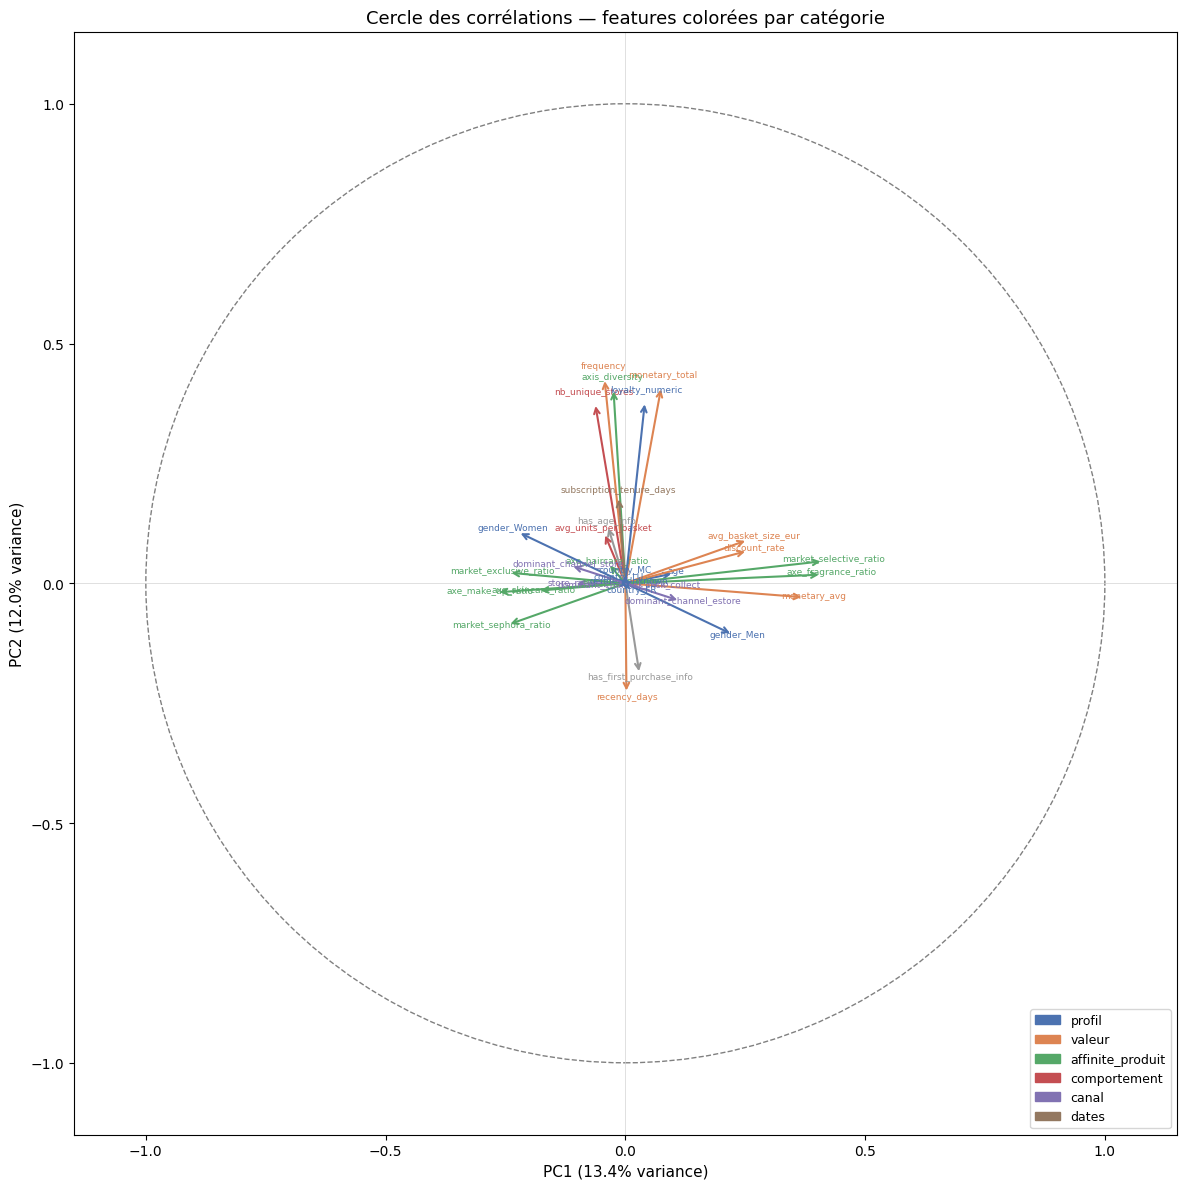

✓ Sauvegardé → figures/correlation_circle.png


In [7]:
fig_corr = plot_correlation_circle(
    X_scaled,
    feature_categories=FEATURE_CATEGORIES,
    category_colors=CATEGORY_COLORS,
    save_path="figures/correlation_circle.png",
)
plt.show()
plt.close(fig_corr)
print("✓ Sauvegardé → figures/correlation_circle.png")

/opt/anaconda3/lib/python3.11/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


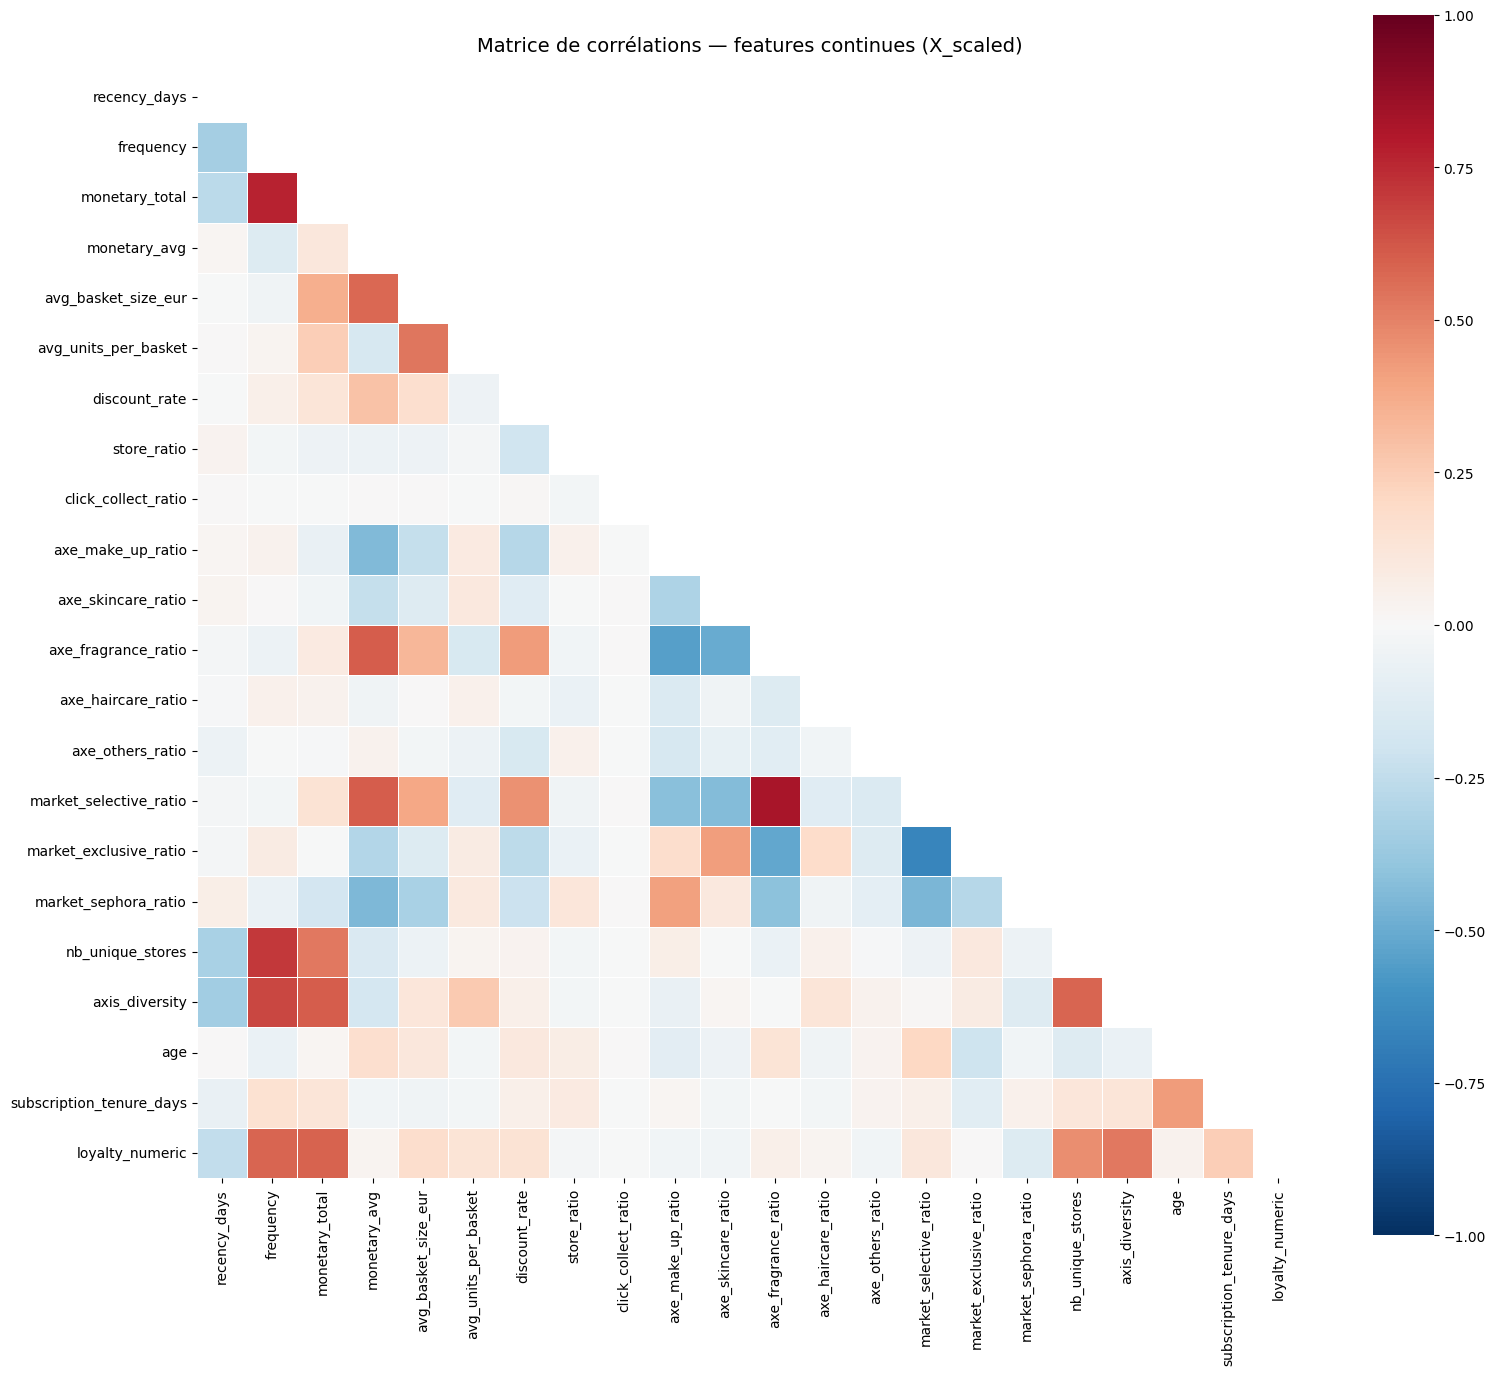

✓ Sauvegardé → figures/correlation_matrix.png

Paires avec |r| > 0.75 :
  axe_fragrance_ratio  ↔  market_selective_ratio  :  r = 0.827
  frequency  ↔  monetary_total  :  r = 0.772


In [8]:
# Matrice de corrélations — features continues uniquement
continuous_in_scaled = [c for c in FEATURES_CONTINUOUS if c in X_scaled.columns]
corr_matrix = X_scaled[continuous_in_scaled].corr()

fig_heatmap, ax_hm = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # affiche uniquement le triangle inférieur
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax_hm,
    annot_kws={"size": 7},
)
ax_hm.set_title("Matrice de corrélations — features continues (X_scaled)", fontsize=14, pad=15)
fig_heatmap.tight_layout()
fig_heatmap.savefig("figures/correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig_heatmap)
print("✓ Sauvegardé → figures/correlation_matrix.png")

# Lister les paires fortement corrélées (|r| > 0.75)
threshold = 0.75
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > threshold:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], r))

if high_corr:
    print(f"\nPaires avec |r| > {threshold} :")
    for f1, f2, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {f1}  ↔  {f2}  :  r = {r:.3f}")
else:
    print(f"\nAucune paire avec |r| > {threshold} détectée ✓")

### Décision (Milan)

> Après inspection du cercle des corrélations, **aucune feature supplémentaire n'a été retirée**.
> Les paires détectées (si elles existent) sont soit sémantiquement distinctes, soit déjà couvertes par les suppressions R1.2.

---
# Section 6 — Clustering : K-Scan (k = 2…30)

On évalue KMeans pour k = 2 à 30 en collectant :
- **Inertia (WCSS)** — méthode du coude : on cherche le point d'inflexion
- **Silhouette** — plus c'est haut, mieux les clusters sont séparés (range -1 à 1)
- **Davies-Bouldin** — plus c'est bas, meilleure est la compacité

Chaque k est tracké dans **MLflow** comme run enfant.

In [9]:
# K-scan avec tracking MLflow
print("Évaluation KMeans k=2..30 avec MLflow tracking…")
metrics_rows = []

with mlflow.start_run(run_name="kmeans-k-scan") as parent_run:
    for k in K_RANGE:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10, max_iter=300)
        labels = km.fit_predict(X_scaled)
        sil_kwargs = {"random_state": RANDOM_STATE}
        if len(X_scaled) > 10_000:
            sil_kwargs["sample_size"] = 10_000
        sil = silhouette_score(X_scaled, labels, **sil_kwargs)
        db  = davies_bouldin_score(X_scaled, labels)
        ch  = calinski_harabasz_score(X_scaled, labels)

        # Log as steps in parent run → MLflow affiche des courbes complètes
        mlflow.log_metrics(
            {"silhouette": sil, "davies_bouldin": db,
             "calinski_harabasz": ch, "inertia": km.inertia_},
            step=k,
        )

        log_clustering_run(
            run_name=f"kmeans-k{k}",
            params={"k": k, "algorithm": "kmeans"},
            metrics={"silhouette": sil, "davies_bouldin": db,
                     "calinski_harabasz": ch, "inertia": km.inertia_},
            parent_run_id=parent_run.info.run_id,
        )
        metrics_rows.append({"k": k, "inertia": km.inertia_,
                             "silhouette": sil, "davies_bouldin": db,
                             "calinski_harabasz": ch})

metrics_df = pd.DataFrame(metrics_rows)
print(f"✓ {len(metrics_df)} valeurs de k évaluées et loguées dans MLflow.")


Évaluation KMeans k=2..30 avec MLflow tracking…


✓ 29 valeurs de k évaluées et loguées dans MLflow.


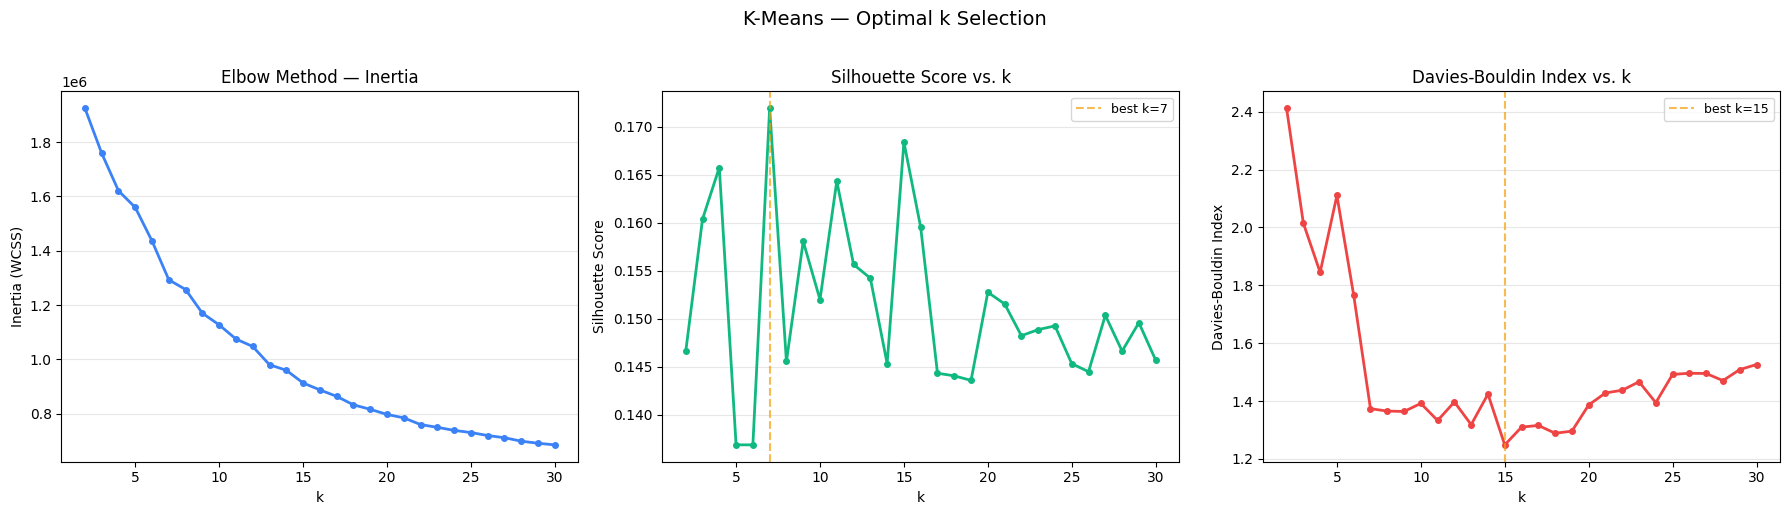

✓ Sauvegardé → figures/elbow_curve.png


In [10]:
# Courbe du coude (inertia, silhouette, Davies-Bouldin)
fig_elbow = plot_elbow_curves(metrics_df, save_path="figures/elbow_curve.png")
plt.show()
plt.close(fig_elbow)
print("✓ Sauvegardé → figures/elbow_curve.png")

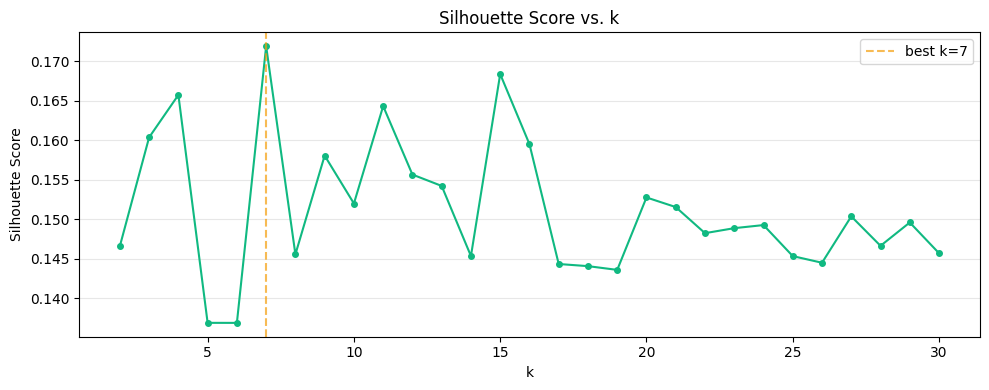

✓ Sauvegardé → figures/silhouette_curve.png


In [11]:
# Courbe silhouette seule (zoom)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(metrics_df["k"], metrics_df["silhouette"], "o-", color="#10B981", markersize=4)
best_k_sil = int(metrics_df.loc[metrics_df["silhouette"].idxmax(), "k"])
ax.axvline(best_k_sil, color="#F59E0B", linestyle="--", alpha=0.7, label=f"best k={best_k_sil}")
ax.set_xlabel("k"); ax.set_ylabel("Silhouette Score"); ax.set_title("Silhouette Score vs. k")
ax.legend(); ax.grid(axis="y", alpha=0.3)
fig.tight_layout(); fig.savefig("figures/silhouette_curve.png", dpi=150)
plt.show(); plt.close(fig)
print("✓ Sauvegardé → figures/silhouette_curve.png")

### Choix de k (Milan)

> **`k_optimal = X`** — choisi parce que …
>
> *(Remplir après inspection des courbes ci-dessus.)*

In [12]:
# ⬇️  Milan : remplacer X par le k choisi
k_optimal = 10  # placeholder — à ajuster après inspection des courbes
print(f"k_optimal = {k_optimal}")

k_optimal = 10


---
# Section 6b — Diagnostic visuel

Deux visualisations complémentaires pour valider le choix de `k_optimal` :

- **Silhouette plot** — montre la largeur de silhouette de chaque point par cluster. Les clusters homogènes ont des barres larges et alignées. Les barres négatives signalent des points mal attribués.
- **UMAP** — projection 2D non-linéaire de `X_scaled` colorée par label KMeans. Permet de vérifier la séparabilité géométrique des clusters.

/var/folders/84/zqd10b2n6jd17bm5tfw84l680000gn/T/ipykernel_46660/295989841.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", k_optimal)


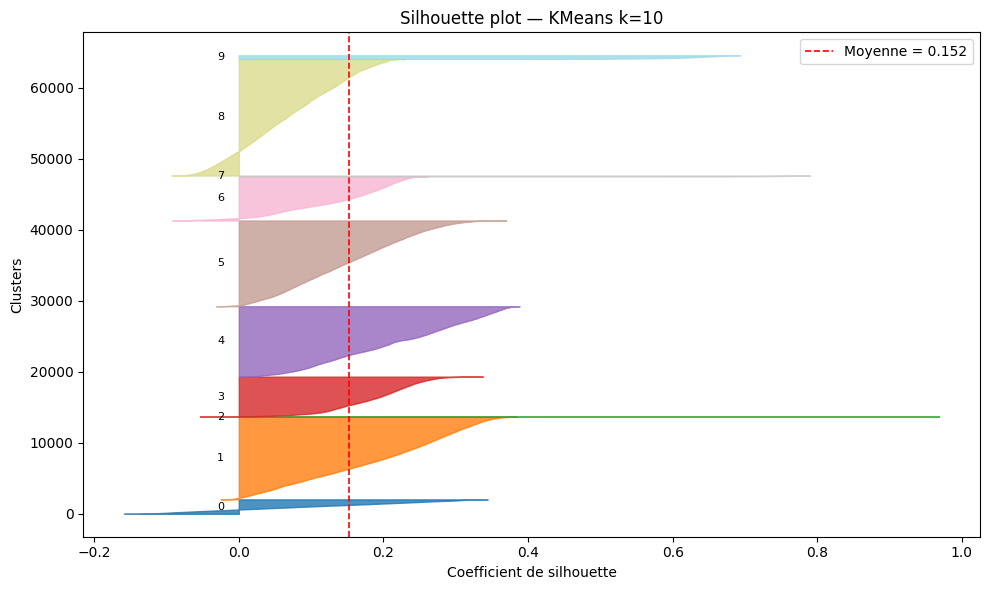

✓ Silhouette moyenne = 0.1520 | Sauvegardé → figures/silhouette_plot.png + loggé dans MLflow


In [13]:
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

# KMeans avec k_optimal pour le diagnostic (identique au modèle final)
_km_diag = KMeans(n_clusters=k_optimal, random_state=RANDOM_STATE, n_init=10, max_iter=300)
_labels_diag = _km_diag.fit_predict(X_scaled)

_sample_sil = silhouette_samples(X_scaled, _labels_diag)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
cmap = cm.get_cmap("tab20", k_optimal)

for i in range(k_optimal):
    ith_sil = np.sort(_sample_sil[_labels_diag == i])
    size_i = ith_sil.shape[0]
    y_upper = y_lower + size_i

    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil,
                     facecolor=cmap(i), edgecolor=cmap(i), alpha=0.8)
    ax.text(-0.03, y_lower + 0.5 * size_i, str(i), fontsize=8, va="center")
    y_lower = y_upper + 10

avg_sil = _sample_sil.mean()
ax.axvline(avg_sil, color="red", linestyle="--", linewidth=1.2,
           label=f"Moyenne = {avg_sil:.3f}")
ax.set_xlabel("Coefficient de silhouette")
ax.set_ylabel("Clusters")
ax.set_title(f"Silhouette plot — KMeans k={k_optimal}")
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig("figures/silhouette_plot.png", dpi=150)
plt.show()
plt.close(fig)

# Log le silhouette plot dans MLflow
with mlflow.start_run(run_name="silhouette-plot"):
    mlflow.log_param("k", k_optimal)
    mlflow.log_metric("silhouette_mean", avg_sil)
    mlflow.log_artifact("figures/silhouette_plot.png", artifact_path="figures")

print(f"✓ Silhouette moyenne = {avg_sil:.4f} | Sauvegardé → figures/silhouette_plot.png + loggé dans MLflow")

In [ ]:
import umap

print("Calcul UMAP (2 composantes) sur X_scaled…")
reducer = umap.UMAP(n_components=2, random_state=RANDOM_STATE, n_neighbors=30, min_dist=0.1)
X_umap = reducer.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(11, 8))
cmap = cm.get_cmap("tab20", k_optimal)
for i in range(k_optimal):
    mask = _labels_diag == i
    ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
               s=6, alpha=0.5, color=cmap(i), label=f"Cluster {i}")

ax.set_title(f"UMAP — KMeans k={k_optimal}", fontsize=13)
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
ax.legend(markerscale=3, loc="best", fontsize=8, ncol=2)
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig("figures/umap_clusters.png", dpi=150)
plt.show()
plt.close(fig)
print("✓ Sauvegardé → figures/umap_clusters.png")

---
# Section 7 — Clustering : Modèle Final

On lance KMeans et le clustering hiérarchique (Ward) avec `k_optimal`, puis on compare les métriques pour choisir le modèle final. Les deux runs sont loggés dans MLflow.

In [ ]:
# --- KMeans final ---
assert (df_customers.index == X_scaled.index).all(), "Index mismatch"
labels_km, km_model = run_kmeans_final(X_scaled, k=k_optimal, random_state=RANDOM_STATE)
df_customers["kmeans_label"] = labels_km

sil_kwargs = {"random_state": RANDOM_STATE}
if len(X_scaled) > 10_000:
    sil_kwargs["sample_size"] = 10_000

sil_km = silhouette_score(X_scaled, labels_km, **sil_kwargs)
db_km  = davies_bouldin_score(X_scaled, labels_km)
ch_km  = calinski_harabasz_score(X_scaled, labels_km)

log_clustering_run(
    run_name="kmeans-final",
    params={"k": k_optimal, "algorithm": "kmeans",
            "n_features": X_scaled.shape[1], "random_state": RANDOM_STATE},
    metrics={"silhouette": sil_km, "davies_bouldin": db_km, "calinski_harabasz": ch_km},
)
print(f"✅ KMeans final (k={k_optimal}) — sil={sil_km:.4f}, DB={db_km:.4f}, CH={ch_km:.1f}")

In [ ]:
# Distribution des clusters KMeans
print(f"Distribution des clusters KMeans (k={k_optimal}):")
counts = df_customers["kmeans_label"].value_counts().sort_index()
pcts = df_customers["kmeans_label"].value_counts(normalize=True).sort_index() * 100
for cid in counts.index:
    print(f"  Cluster {cid}: {counts[cid]:>6,} clients ({pcts[cid]:5.2f}%)")

In [ ]:
# --- Clustering hiérarchique (Ward) ---
# ⬇️  Milan : définir le nombre de lignes à utiliser (None = dataset complet, mais très lent)
hc_n_samples = 3000 # ex: 5000, 10_000, None

labels_hc = run_hierarchical(X_scaled, k=k_optimal, n_samples=hc_n_samples)
df_customers["hclust_label"] = labels_hc

sil_hc = silhouette_score(X_scaled, labels_hc, **sil_kwargs)
db_hc  = davies_bouldin_score(X_scaled, labels_hc)
ch_hc  = calinski_harabasz_score(X_scaled, labels_hc)

log_clustering_run(
    run_name="hierarchical-final",
    params={"k": k_optimal, "algorithm": "agglomerative_ward",
            "n_features": X_scaled.shape[1], "hc_n_samples": hc_n_samples or len(X_scaled)},
    metrics={"silhouette": sil_hc, "davies_bouldin": db_hc, "calinski_harabasz": ch_hc},
)
n_msg = f"(sur {hc_n_samples:,} lignes, propagé sur {len(X_scaled):,})" if hc_n_samples else f"(sur {len(X_scaled):,} lignes)"
print(f"✅ Hierarchical Ward (k={k_optimal}) {n_msg} — sil={sil_hc:.4f}, DB={db_hc:.4f}, CH={ch_hc:.1f}")


In [ ]:
from src.clustering import plot_dendrogram

_dendro_n = min(hc_n_samples or len(X_scaled), 10_000)  # ≤ 2 000 points pour la vitesse
fig_dendro = plot_dendrogram(
    X_scaled,
    k=k_optimal,
    n_samples=_dendro_n,
    save_path="figures/dendrogram.png",
)
plt.show()
plt.close(fig_dendro)

# Log dans MLflow comme artifact lié au run hiérarchique
with mlflow.start_run(run_name="hierarchical-dendrogram"):
    mlflow.log_param("k", k_optimal)
    mlflow.log_param("dendro_n_samples", _dendro_n)
    mlflow.log_artifact("figures/dendrogram.png", artifact_path="figures")

print(f"✓ Dendrogramme (sur {_dendro_n:,} points) — sauvegardé → figures/dendrogram.png + loggé dans MLflow")


In [ ]:
# Tableau comparatif KMeans vs Hierarchical (sera mis à jour après GMM)
comparison_results = [
    {"Algorithme": "KMeans", "Silhouette": sil_km, "Davies-Bouldin": db_km, "Calinski-Harabasz": ch_km},
    {"Algorithme": "Hierarchical (Ward)", "Silhouette": sil_hc, "Davies-Bouldin": db_hc, "Calinski-Harabasz": ch_hc},
]
comparison = pd.DataFrame(comparison_results)
print(comparison.to_string(index=False))

---
## US-4.4 — Gaussian Mixture Models (GMM)

Le GMM est un modèle de clustering *soft* (probabiliste) : chaque client a une probabilité d'appartenir à chaque cluster.
On utilise `covariance_type='diag'` car avec 43 features, `'full'` est numériquement instable et trop lent.

In [ ]:
# --- Reload modules just in case ---
import sys, importlib
import src.clustering, src.visualization
importlib.reload(src.clustering)
importlib.reload(src.visualization)

# --- Task 2: BIC / AIC curves ---
from src.clustering import evaluate_gmm_bic_aic
from src.visualization import plot_gmm_bic_aic

bic_aic_df = evaluate_gmm_bic_aic(X_scaled, k_range=range(2, 21))
fig_bic = plot_gmm_bic_aic(bic_aic_df, save_path="figures/gmm_bic_aic.png")
plt.show()
plt.close(fig_bic)

best_bic_k = int(bic_aic_df.loc[bic_aic_df["bic"].idxmin(), "k"])
print(f"✅ BIC/AIC évalués pour k=2..20 — best BIC à k={best_bic_k}")
print(f"   Sauvegardé → figures/gmm_bic_aic.png")

In [ ]:
# --- Task 1 & 3: Run GMM final + compute metrics ---
from src.clustering import run_gmm

labels_gmm, gmm_model = run_gmm(X_scaled, k=k_optimal)
df_customers["gmm_label"] = labels_gmm

sil_gmm = silhouette_score(X_scaled, labels_gmm, **sil_kwargs)
db_gmm  = davies_bouldin_score(X_scaled, labels_gmm)
ch_gmm  = calinski_harabasz_score(X_scaled, labels_gmm)

print(f"✅ GMM (k={k_optimal}, covariance='diag') — sil={sil_gmm:.4f}, DB={db_gmm:.4f}, CH={ch_gmm:.1f}")
print(f"   Converged: {gmm_model.converged_}, n_iter: {gmm_model.n_iter_}")

In [ ]:
# --- Task 4: Log GMM run to MLflow ---
# Calcul du min_cluster_pct
gmm_counts = pd.Series(labels_gmm).value_counts(normalize=True)
min_cluster_pct = gmm_counts.min() * 100

log_clustering_run(
    run_name="gmm-final",
    params={
        "k": k_optimal,
        "algorithm": "gmm_diag",
        "n_features": X_scaled.shape[1],
        "random_state": RANDOM_STATE,
    },
    metrics={
        "silhouette": sil_gmm,
        "davies_bouldin": db_gmm,
        "calinski_harabasz": ch_gmm,
        "min_cluster_pct": min_cluster_pct,
    },
)
print(f"✅ MLflow run 'gmm-final' loggé — min_cluster_pct={min_cluster_pct:.2f}%")

---
## US-4.7 — HDBSCAN (Hierarchical Density-Based Spatial Clustering)

HDBSCAN est un algorithme de clustering basé sur la densité. Contrairement à KMeans/GMM, il :
- **Ne nécessite pas de spécifier k** : il découvre le nombre de clusters naturels
- **Détecte le bruit** : les points isolés sont étiquetés `-1` (noise)
- **S'adapte aux densités variables** : trouve des clusters de formes et densités différentes

Le paramètre principal est `min_cluster_size` (taille minimale pour qu'un groupe soit un cluster).

In [ ]:
# --- Task 2: min_cluster_size sweep ---
import sys, importlib
import src.clustering
importlib.reload(src.clustering)
from src.clustering import run_hdbscan

sweep_values = [100, 200, 500, 1000]
sweep_results = []

for mcs in sweep_values:
    labels_sweep, _ = run_hdbscan(X_scaled, min_cluster_size=mcs, min_samples=5)
    mask = labels_sweep != -1
    n_clusters = len(set(labels_sweep[mask]))
    noise_pct = (~mask).mean() * 100

    if n_clusters >= 2:
        X_no_noise = X_scaled.values[mask]
        labels_no_noise = labels_sweep[mask]
        sil_kw = {"random_state": RANDOM_STATE}
        if len(X_no_noise) > 10_000:
            sil_kw["sample_size"] = 10_000
        sil = silhouette_score(X_no_noise, labels_no_noise, **sil_kw)
    else:
        sil = float("nan")

    sweep_results.append({
        "min_cluster_size": mcs,
        "n_clusters": n_clusters,
        "noise_pct": round(noise_pct, 2),
        "silhouette": round(sil, 4) if not np.isnan(sil) else sil,
    })

sweep_df = pd.DataFrame(sweep_results)
print("📊 HDBSCAN — min_cluster_size sweep:")
print(sweep_df.to_string(index=False))

# Choose best: best silhouette with noise% < 10%; else lowest noise%
candidates = sweep_df[sweep_df["noise_pct"] < 10]
if len(candidates) > 0:
    best_idx = candidates["silhouette"].idxmax()
else:
    best_idx = sweep_df["noise_pct"].idxmin()

best_mcs = int(sweep_df.loc[best_idx, "min_cluster_size"])
print(f"\n✅ Best min_cluster_size = {best_mcs} (sil={sweep_df.loc[best_idx, 'silhouette']}, noise={sweep_df.loc[best_idx, 'noise_pct']}%)")

In [ ]:
# --- Task 3: Final HDBSCAN run + label assignment ---
labels_hdbscan, hdbscan_model = run_hdbscan(X_scaled, min_cluster_size=best_mcs, min_samples=5)
df_customers["hdbscan_label"] = labels_hdbscan

mask = labels_hdbscan != -1
n_clusters_hdb = len(set(labels_hdbscan[mask]))
n_noise = int((~mask).sum())
noise_pct = (~mask).mean() * 100

print(f"✅ HDBSCAN final (min_cluster_size={best_mcs}, min_samples=5, method='eom')")
print(f"   n_clusters = {n_clusters_hdb}")
print(f"   n_noise    = {n_noise:,} ({noise_pct:.2f}%)")

In [ ]:
# --- Task 5: UMAP scatter plot ---
fig, ax = plt.subplots(figsize=(10, 7))
cmap = plt.cm.tab20  # tab20 allows 20 distinct colors instead of 10
unique_labels = sorted(set(labels_hdbscan))
for lbl in unique_labels:
    mask_lbl = labels_hdbscan == lbl
    color = "grey" if lbl == -1 else cmap(lbl % 20)
    label_str = "Noise" if lbl == -1 else f"Cluster {lbl}"
    ax.scatter(umap_embedding[mask_lbl, 0], umap_embedding[mask_lbl, 1],
               c=[color], s=2, alpha=0.5, label=label_str)
ax.set_title("HDBSCAN — UMAP projection")
ax.legend(markerscale=4, loc="best")
fig.tight_layout()
fig.savefig("figures/hdbscan_umap.png", dpi=150)
plt.show()
plt.close(fig)
print("✅ Sauvegardé → figures/hdbscan_umap.png")

In [ ]:
# --- Task 5: UMAP scatter plot ---
fig, ax = plt.subplots(figsize=(10, 7))
cmap = plt.cm.tab10
unique_labels = sorted(set(labels_hdbscan))
for lbl in unique_labels:
    mask_lbl = labels_hdbscan == lbl
    color = "grey" if lbl == -1 else cmap(lbl % 10)
    label_str = "Noise" if lbl == -1 else f"Cluster {lbl}"
    ax.scatter(umap_embedding[mask_lbl, 0], umap_embedding[mask_lbl, 1],
               c=[color], s=2, alpha=0.5, label=label_str)
ax.set_title("HDBSCAN — UMAP projection")
ax.legend(markerscale=4, loc="best")
fig.tight_layout()
fig.savefig("figures/hdbscan_umap.png", dpi=150)
plt.show()
plt.close(fig)
print("✅ Sauvegardé → figures/hdbscan_umap.png")

In [ ]:
# --- Task 6: Log HDBSCAN run to MLflow ---
with mlflow.start_run(run_name="hdbscan-final"):
    mlflow.log_params({
        "algorithm": "hdbscan",
        "min_cluster_size": best_mcs,
        "min_samples": 5,
        "cluster_selection_method": "eom",
        "n_features": X_scaled.shape[1],
    })
    mlflow.log_metrics({
        "n_clusters": n_clusters_hdb,
        "noise_pct": noise_pct,
        "silhouette": sil_hdb,
        "davies_bouldin": db_hdb,
        "calinski_harabasz": ch_hdb,
    })

print(f"✅ MLflow run 'hdbscan-final' loggé")
print(f"   Params: min_cluster_size={best_mcs}, min_samples=5, method=eom, n_features={X_scaled.shape[1]}")
print(f"   Metrics: n_clusters={n_clusters_hdb}, noise_pct={noise_pct:.2f}%, sil={sil_hdb:.4f}")

---
## US-4.8 — DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

DBSCAN est un deuxième algorithme basé sur la densité. Contrairement à HDBSCAN, il requiert un paramètre `eps` (rayon du voisinage) fixé par l'utilisateur.

**Approche :**
1. Tracer le **k-distance graph** pour identifier le coude → candidat `eps`
2. Lancer DBSCAN avec `eps` choisi et `min_samples=5`
3. Si le bruit dépasse 30%, relancer avec un `eps` plus grand
4. Calculer les métriques sur les points non-bruit uniquement

In [ ]:
# --- US-4.8 Task 1: k-distance graph for eps selection ---
import sys, importlib
import src.clustering
importlib.reload(src.clustering)
from src.clustering import plot_kdistance

fig_kd = plot_kdistance(X_scaled, k=5, save_path="figures/dbscan_kdistance.png")
plt.show()
plt.close(fig_kd)
print("✅ k-distance graph sauvegardé → figures/dbscan_kdistance.png")
print("   Identifier le coude de la courbe pour choisir eps")

### Choix de `eps` (AC-3)

**Valeur choisie :** `eps = ___` *(à remplir après inspection du k-distance graph ci-dessus)*

**Raisonnement :** Le coude du k-distance graph se situe autour de `___`. C'est la valeur à partir de laquelle la distance au 5e voisin augmente fortement, indiquant la transition entre zones denses et zones clairsemées.

In [ ]:
# --- US-4.8 Task 4: DBSCAN run + noise check + optional re-run ---
from src.clustering import run_dbscan

# Initial eps — adjust after inspecting k-distance graph elbow
eps_chosen = 2.0

labels_dbscan, dbscan_model = run_dbscan(X_scaled, eps=eps_chosen, min_samples=5)
df_customers["dbscan_label"] = labels_dbscan

mask_db = labels_dbscan != -1
n_clusters_db = len(set(labels_dbscan[mask_db])) if mask_db.any() else 0
n_noise_db = int((~mask_db).sum())
noise_pct_db = (~mask_db).mean() * 100

print(f"✅ DBSCAN (eps={eps_chosen}, min_samples=5)")
print(f"   n_clusters = {n_clusters_db}")
print(f"   n_noise    = {n_noise_db:,} ({noise_pct_db:.2f}%)")

# AC-6: If noise% > 30%, try larger eps
if noise_pct_db > 30:
    eps_retry = round(eps_chosen * 1.3, 2)
    print(f"\n⚠️ Noise > 30% — relance avec eps={eps_retry}")
    labels_dbscan2, dbscan_model2 = run_dbscan(X_scaled, eps=eps_retry, min_samples=5)
    mask_db2 = labels_dbscan2 != -1
    n_clusters_db2 = len(set(labels_dbscan2[mask_db2])) if mask_db2.any() else 0
    noise_pct_db2 = (~mask_db2).mean() * 100
    print(f"   eps={eps_retry}: n_clusters={n_clusters_db2}, noise={noise_pct_db2:.2f}%")

    # Keep the run with less noise if it still has ≥2 clusters
    if noise_pct_db2 < noise_pct_db and n_clusters_db2 >= 2:
        print(f"   → Retenu eps={eps_retry}")
        eps_chosen = eps_retry
        labels_dbscan = labels_dbscan2
        dbscan_model = dbscan_model2
        df_customers["dbscan_label"] = labels_dbscan
        mask_db = mask_db2
        n_clusters_db = n_clusters_db2
        noise_pct_db = noise_pct_db2
    else:
        print(f"   → Conservé eps={eps_chosen} (le retry n'améliore pas)")

print(f"\n📌 eps final = {eps_chosen}, n_clusters = {n_clusters_db}, noise = {noise_pct_db:.2f}%")

In [ ]:
# --- US-4.8 Task 5: Compute metrics on non-noise points ---
X_no_noise_db = X_scaled.values[mask_db]
labels_no_noise_db = labels_dbscan[mask_db]

if n_clusters_db >= 2:
    sil_kwargs_db = {"random_state": RANDOM_STATE}
    if len(X_no_noise_db) > 10_000:
        sil_kwargs_db["sample_size"] = 10_000
    sil_db = silhouette_score(X_no_noise_db, labels_no_noise_db, **sil_kwargs_db)
    db_db = davies_bouldin_score(X_no_noise_db, labels_no_noise_db)
    ch_db = calinski_harabasz_score(X_no_noise_db, labels_no_noise_db)
else:
    sil_db = db_db = ch_db = float("nan")

print(f"📊 DBSCAN Metrics (non-noise points only, n={mask_db.sum():,}):")
print(f"   Silhouette       = {sil_db:.4f}" if not np.isnan(sil_db) else "   Silhouette       = NaN")
print(f"   Davies-Bouldin   = {db_db:.4f}" if not np.isnan(db_db) else "   Davies-Bouldin   = NaN")
print(f"   Calinski-Harabasz = {ch_db:.1f}" if not np.isnan(ch_db) else "   Calinski-Harabasz = NaN")

# Append to comparison_results (AC-7)
comparison_results.append({
    "algorithm": "DBSCAN",
    "k": n_clusters_db,
    "silhouette": sil_db,
    "davies_bouldin": db_db,
    "calinski_harabasz": ch_db,
    "noise_pct": noise_pct_db,
    "label_col": "dbscan_label",
})
print(f"\n✅ DBSCAN ajouté à comparison_results ({len(comparison_results)} entries)")

In [ ]:
# --- US-4.8 Task 6: UMAP scatter plot ---
fig, ax = plt.subplots(figsize=(10, 7))
cmap = plt.cm.tab10
unique_labels_db = sorted(set(labels_dbscan))
for lbl in unique_labels_db:
    mask_lbl = labels_dbscan == lbl
    color = "grey" if lbl == -1 else cmap(lbl % 10)
    label_str = "Noise" if lbl == -1 else f"Cluster {lbl}"
    ax.scatter(umap_embedding[mask_lbl, 0], umap_embedding[mask_lbl, 1],
               c=[color], s=2, alpha=0.5, label=label_str)
ax.set_title(f"DBSCAN (eps={eps_chosen}) — UMAP projection")
ax.legend(markerscale=4, loc="best")
fig.tight_layout()
fig.savefig("figures/dbscan_umap.png", dpi=150)
plt.show()
plt.close(fig)
print("✅ Sauvegardé → figures/dbscan_umap.png")

In [ ]:
# --- US-4.8 Task 7: MLflow logging ---
with mlflow.start_run(run_name="dbscan-final"):
    mlflow.log_params({
        "algorithm": "dbscan",
        "eps": eps_chosen,
        "min_samples": 5,
        "n_features": X_scaled.shape[1],
    })
    mlflow.log_metrics({
        "n_clusters": n_clusters_db,
        "noise_pct": noise_pct_db,
        "silhouette": sil_db if not np.isnan(sil_db) else 0.0,
        "davies_bouldin": db_db if not np.isnan(db_db) else 0.0,
        "calinski_harabasz": ch_db if not np.isnan(ch_db) else 0.0,
    })

print(f"✅ MLflow run 'dbscan-final' loggé")
print(f"   Params: eps={eps_chosen}, min_samples=5, n_features={X_scaled.shape[1]}")
print(f"   Metrics: n_clusters={n_clusters_db}, noise_pct={noise_pct_db:.2f}%")

In [ ]:
# --- US-4.5 Task 1: Build comparison table with min_cluster_pct ---
import sys, importlib
import src.clustering
importlib.reload(src.clustering)
from src.clustering import build_comparison_table, select_best_algorithm

# Do not recreate comparison_results entirely, it was appended progressively!
# Just build table directly
comp_df = build_comparison_table(comparison_results, df_customers)
print("📊 Algorithm Comparison Table (US-4.5 — AC 1):")
print(comp_df.to_string(index=False))
print()

# --- US-4.5 Task 2: Select best algorithm ---
best_row = select_best_algorithm(comp_df)
best_algo = best_row["algorithm"]
print(f"🏆 Best algorithm: {best_algo} (score={best_row['score']:.4f})")

In [ ]:
# --- US-4.5 Task 4: Log comparison table to MLflow ---
comp_csv_path = "data/processed/comparison_results.csv"
comp_df.to_csv(comp_csv_path, index=False)

with mlflow.start_run(run_name="algorithm-comparison"):
    mlflow.log_artifact(comp_csv_path, artifact_path="comparison")
    mlflow.log_param("best_algorithm", best_algo)
    mlflow.log_metric("best_silhouette", float(best_row["silhouette"]))

print(f"✅ MLflow run 'algorithm-comparison' — comparison_results.csv loggé comme artifact")
print(f"   Fichier local: {comp_csv_path}")

---
## US-4.5 — Algorithm Comparison & Final Selection

Le tableau ci-dessus compare KMeans, Hierarchical (Ward) et GMM sur les métriques Silhouette, Davies-Bouldin, Calinski-Harabasz et la taille minimale de cluster.  
Le meilleur algorithme est sélectionné automatiquement via un score combiné.

### Justification du choix (Milan)

> **Modèle retenu :** *(Remplir après inspection du tableau ci-dessus, ex: KMeans)*
>
> **Raisons :** *(3-5 phrases justifiant le choix : meilleure silhouette, clusters équilibrés, reproductibilité, etc.)*

---
# Section 8 — Profiling des segments

On compare la moyenne de chaque feature par cluster à la moyenne globale. Les valeurs sont exprimées en **z-scores** (écarts par rapport à la moyenne globale en unités d'écart-type). Une valeur de +1.5 signifie que le cluster est 1.5 écarts-types au-dessus de la moyenne.

In [ ]:
# --- US-4.5 Task 2 (cont.): Assign final_cluster + cluster_id ---
# Map best algorithm name to its label column in df_customers
ALGO_TO_LABEL_COL = {
    "KMeans": "kmeans_label",
    "Hierarchical (Ward)": "hclust_label",
    "GMM (diag)": "gmm_label",
    "HDBSCAN": "hdbscan_label",
    "DBSCAN": "dbscan_label",
}
label_col = ALGO_TO_LABEL_COL[best_algo]
df_customers["final_cluster"] = df_customers[label_col]
df_customers["cluster_id"] = df_customers["final_cluster"].apply(lambda x: f"C{x}")

print(f"✅ final_cluster assigné depuis '{label_col}' ({best_algo})")
print(f"   Colonnes ajoutées: 'final_cluster', 'cluster_id'")
print(f"   Distribution:")
print(df_customers["final_cluster"].value_counts().sort_index())

In [ ]:
# ⬇️  Milan : lister les clusters à masquer du heatmap (liste vide = tous affichés)
CLUSTERS_TO_HIDE = []

In [ ]:
# Heatmap des profils
zscore_plot = zscore_df.drop(index=[c for c in CLUSTERS_TO_HIDE if c in zscore_df.index])

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(zscore_plot.T, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            linewidths=0.5, cbar_kws={"label": "Z-score vs. moyenne globale"})
hidden_msg = f" — clusters masqués : {CLUSTERS_TO_HIDE}" if CLUSTERS_TO_HIDE else ""
ax.set_title(f"Profil des segments (k={k_optimal}){hidden_msg} — Z-score vs. moyenne globale", fontsize=13)
ax.set_xlabel("Cluster"); ax.set_ylabel("Feature")
fig.tight_layout()
fig.savefig("figures/cluster_profiles.png", dpi=150)
plt.show(); plt.close(fig)
print("✓ Sauvegardé → figures/cluster_profiles.png")

### Observations clés par cluster (Milan), vont changer si le modèle ou les hyperparamètres changent

> **Cluster 0 :** CLIENTS FIDÈLES : haute fréquence d'achat, beaucoup de dépense, dans différents stores, haute fidélité, mais volume par achat moyen : ils viennent souvent mais n'achètent pas tant que ça
>
> **Cluster 1 :** Ne viennent pas si souvent mais achètent beaucoup, sont vieux.
>
> **Cluster 2 :** N'achètent peu, un peu vieux
>
> **Cluster 3 :** Achètent en ligne, peu en stores
>
> **Cluster 4 :** N'achètent peu, un peu jeune
>
> **Cluster 5 :** Très moyen
>
> **Cluster 6 :** 
>
> **Cluster 7 :** 
>
> **Cluster 8 :** 
>
> **Cluster 9 :** 
> *(À remplir après inspection de la heatmap.)*

---
# Section 9 — Export

On exporte le DataFrame `df_customers` enrichi des labels de cluster vers un fichier CSV
pour analyse ultérieure ou intégration dans un dashboard.

In [ ]:
# --- US-4.5 Task 3: Export customers_with_clusters.csv ---
assert "final_cluster" in df_customers.columns, "final_cluster missing!"
assert "cluster_id" in df_customers.columns, "cluster_id missing!"

df_customers.to_csv("data/processed/customers_with_clusters.csv", index=False)
last_cols = list(df_customers.columns[-4:])
print(f"✅ Exported: {len(df_customers):,} rows → data/processed/customers_with_clusters.csv")
print(f"   Dernières colonnes: {last_cols}")

In [ ]:
print("Pour parcourir les expériences MLflow :")
print("  mlflow ui")
print("  → http://127.0.0.1:5000")

---
# Section 10 — US-4.6 : Cluster Stability Validation (Bootstrap)

On teste la stabilité du clustering final en ré-exécutant l'algorithme retenu sur **5 sous-échantillons bootstrap (80%)** du jeu de données. L'**Adjusted Rand Index (ARI)** mesure la concordance entre les labels du sous-échantillon et les labels du jeu complet.

- **Seuil : Mean ARI ≥ 0.70** → clustering stable
- Si Mean ARI < 0.70 → instabilité détectée, réviser k ou l'algorithme

In [ ]:
# --- US-4.6 Task 1: Bootstrap stability ---
from src.validation import bootstrap_stability
from src.clustering import run_kmeans_final

# Wrap the chosen algorithm as a callable
def final_algo(X_sub):
    labels, _ = run_kmeans_final(X_sub, k_optimal)
    return labels

stability_df = bootstrap_stability(X_scaled, df_customers["final_cluster"], final_algo)
print(stability_df.to_string(index=False))
print(f"\nMean ARI: {stability_df['ari'].mean():.3f}")
print(f"Min  ARI: {stability_df['ari'].min():.3f}")
print(f"Max  ARI: {stability_df['ari'].max():.3f}")

In [ ]:
# --- US-4.6 Task 2: Evaluate stability threshold ---
mean_ari = stability_df["ari"].mean()
if mean_ari >= 0.70:
    print(f"✓ Stable clustering (Mean ARI = {mean_ari:.3f} ≥ 0.70)")
else:
    print(f"⚠ Unstable clustering (Mean ARI = {mean_ari:.3f} < 0.70)")
    print("Consider: reduce k, try different algorithm, or review feature selection")

In [ ]:
# --- US-4.6 Task 4: Log stability results to MLflow ---
import mlflow

mean_ari = stability_df["ari"].mean()
min_ari = stability_df["ari"].min()
max_ari = stability_df["ari"].max()

with mlflow.start_run(run_name="stability-validation"):
    mlflow.log_params({
        "n_bootstraps": 5,
        "subsample_frac": 0.80,
        "algorithm": best_algo,
        "k": k_optimal,
    })
    mlflow.log_metrics({
        "mean_ari": mean_ari,
        "min_ari": min_ari,
        "max_ari": max_ari,
    })
    stability_csv = "data/processed/stability_results.csv"
    stability_df.to_csv(stability_csv, index=False)
    mlflow.log_artifact(stability_csv, artifact_path="validation")

print(f"✅ MLflow run 'stability-validation' loggé")
print(f"   Params: n_bootstraps=5, subsample_frac=0.80, algorithm={best_algo}, k={k_optimal}")
print(f"   Metrics: mean_ari={mean_ari:.4f}, min_ari={min_ari:.4f}, max_ari={max_ari:.4f}")
print(f"   Artifact: {stability_csv}")

---
## E4 — Synthèse finale

| Élément | Valeur |
|---|---|
| **Algorithme retenu** | Sélectionné automatiquement (US-4.5) |
| **k optimal** | Déterminé par silhouette (US-4.1) |
| **Stabilité (Mean ARI)** | Calculé ci-dessus (seuil ≥ 0.70) |
| **Colonne finale** | `df_customers['final_cluster']` |

**Gate statement:** Clustering complete — proceeding to E5 Segment Profiling.

In [ ]:
cd "/Users/milanviallet/Documents - MacBook Air de Milan/Albert/B2/BDD/Sephora" && mlflow ui